In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/airlines_flights_data.csv")
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


- Datasetdə hansı aviaşirkətlər var və onların tezlikləri nə qədərdir?

- Gediş vaxtı və Gəliş vaxtını təmsil edən Bar Qrafikləri göstərin.

- Mənbə Şəhəri və Təyinat Şəhəri təmsil edən Bar Qrafikləri göstərin.

- Qiymət aviaşirkətlərə görə dəyişirmi?

- Bilet qiyməti gediş vaxtı və gəliş vaxtına əsasən dəyişirmi?

- Qiymət mənbə və təyinatın dəyişməsi ilə necə dəyişir?

- Biletlər uçuşdan cəmi 1 və ya 2 gün əvvəl alındıqda qiymət necə təsirlənir?

- Bilet qiyməti İqtisadiyyat və Biznes sinfi arasında necə dəyişir?

- Datasetdəki uçuşların orta müddəti (duration) nə qədərdir və bu müddət sinflərə (Economy/Business) görə necə fərqlənir?

- Durak sayı (stops) qiymətə necə təsir edir? (Məsələn, zero, one, two_or_more duraklar üçün orta qiymətləri müqayisə edin.)

- Günlər qalmış (days_left) dəyişkəninə görə qiymətin paylanması necədir? (Məsələn, 1-10 gün, 11-20 gün və s. qruplar üzrə qrafik və ya orta qiymətlər.)

- Hansı mənbə şəhərdən (source_city) ən çox uçuş var və onların orta qiyməti nə qədərdir?

- Biznes sinfində uçuşların ümumi sayı və orta qiyməti İqtisadiyyat sinfi ilə müqayisədə necədir?

- Datasetdəki ən bahalı və ən ucuz uçuşlar hansı aviaşirkətlərə və şəhərlərə aiddir? (Ən azı 5 nümunə verin.)

In [7]:
df.shape

(300153, 12)

In [8]:
df.columns

Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [10]:
df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [12]:
airline_counts = df['airline'].value_counts()
print(airline_counts)

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


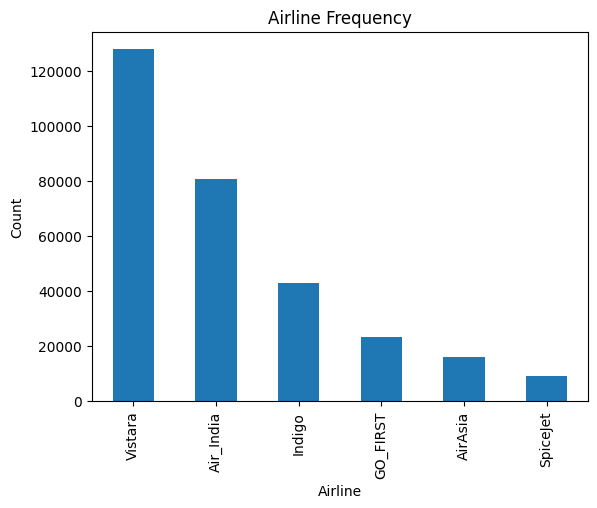

In [13]:
airline_counts.plot(kind='bar')
plt.title("Airline Frequency")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.show()

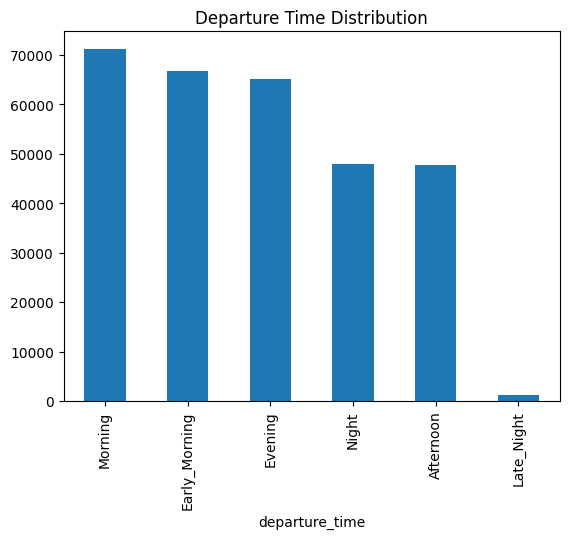

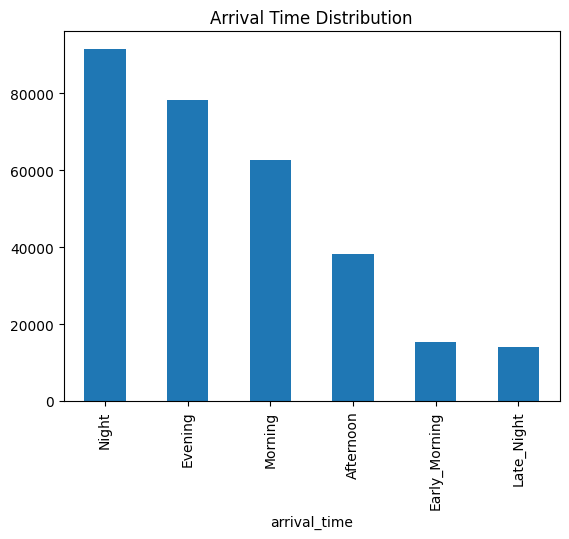

In [17]:
# Departure
df['departure_time'].value_counts().plot(kind='bar')
plt.title("Departure Time Distribution")
plt.show()

# Arrival
df['arrival_time'].value_counts().plot(kind='bar')
plt.title("Arrival Time Distribution")
plt.show()

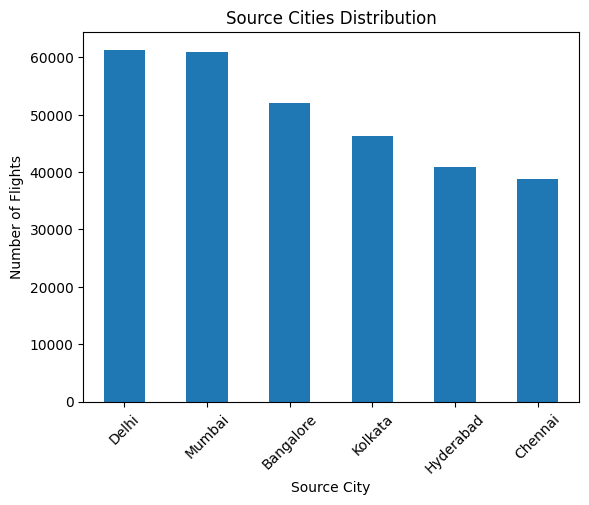

In [18]:
source_counts = df['source_city'].value_counts()

source_counts.plot(kind='bar')
plt.title("Source Cities Distribution")
plt.xlabel("Source City")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

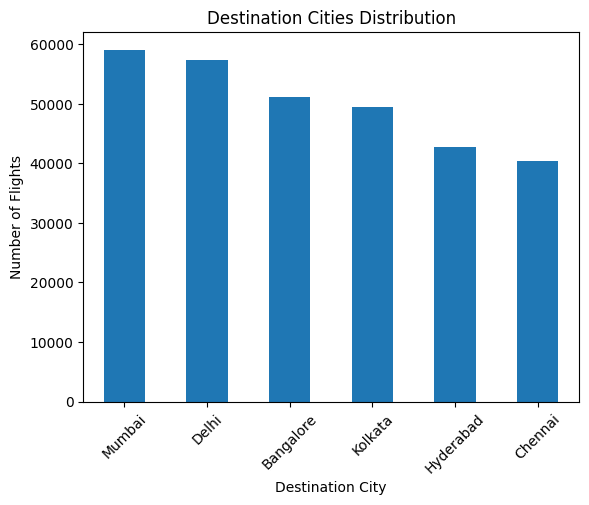

In [19]:
dest_counts = df['destination_city'].value_counts()

dest_counts.plot(kind='bar')
plt.title("Destination Cities Distribution")
plt.xlabel("Destination City")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

In [20]:
price_by_airline = df.groupby('airline')['price'].mean()
print(price_by_airline)

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64


In [21]:
price_dep = df.groupby('departure_time')['price'].mean()
print(price_dep)

departure_time
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Late_Night        9295.299387
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64


In [22]:
price_arr = df.groupby('arrival_time')['price'].mean()
print(price_arr)

arrival_time
Afternoon        18494.598993
Early_Morning    14993.139521
Evening          23044.371615
Late_Night       11284.906078
Morning          22231.076098
Night            21586.758341
Name: price, dtype: float64


In [23]:
price_source = df.groupby('source_city')['price'].mean()
print(price_source)

source_city
Bangalore    21469.460575
Chennai      21995.339871
Delhi        18951.326639
Hyderabad    20155.623879
Kolkata      21746.235679
Mumbai       21483.818839
Name: price, dtype: float64


In [24]:
price_dest = df.groupby('destination_city')['price'].mean()
print(price_dest)

destination_city
Bangalore    21593.955784
Chennai      21953.323969
Delhi        18436.767870
Hyderabad    20427.661284
Kolkata      21959.557556
Mumbai       21372.529469
Name: price, dtype: float64


In [25]:
bins = [0,10,20,30,40,50]
labels = ['1-10','11-20','21-30','31-40','41-50']

df['days_group'] = pd.cut(df['days_left'], bins=bins, labels=labels)

price_days = df.groupby('days_group')['price'].mean()
print(price_days)

days_group
1-10     26082.751717
11-20    21260.475515
21-30    19625.787849
31-40    19393.765657
41-50    19108.742210
Name: price, dtype: float64


/tmp/ipykernel_23178/116844927.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_days = df.groupby('days_group')['price'].mean()


In [26]:
price_class = df.groupby('class')['price'].mean()
print(price_class)

class
Business    52540.081124
Economy      6572.342383
Name: price, dtype: float64


In [27]:
print("Average duration:", df['duration'].mean())

duration_class = df.groupby('class')['duration'].mean()
print(duration_class)

Average duration: 12.221020812718846
class
Business    13.704274
Economy     11.550060
Name: duration, dtype: float64


In [28]:
price_stops = df.groupby('stops')['price'].mean()
print(price_stops)

stops
one            22900.992482
two_or_more    14113.450775
zero            9375.938535
Name: price, dtype: float64


In [29]:
top_city = df['source_city'].value_counts().idxmax()
print("Top city:", top_city)

avg_price = df[df['source_city'] == top_city]['price'].mean()
print("Average price:", avg_price)

Top city: Delhi
Average price: 18951.326638736286


In [30]:
class_counts = df['class'].value_counts()
print(class_counts)

price_class = df.groupby('class')['price'].mean()
print(price_class)

class
Economy     206666
Business     93487
Name: count, dtype: int64
class
Business    52540.081124
Economy      6572.342383
Name: price, dtype: float64


In [31]:
cheapest = df.nsmallest(5, 'price')
print(cheapest[['airline','source_city','destination_city','price']])

         airline source_city destination_city  price
203807   AirAsia     Chennai        Hyderabad   1105
203808  GO_FIRST     Chennai        Hyderabad   1105
203908   AirAsia     Chennai        Hyderabad   1105
203909  GO_FIRST     Chennai        Hyderabad   1105
204003   AirAsia     Chennai        Hyderabad   1105


In [32]:
expensive = df.nlargest(5, 'price')
print(expensive[['airline','source_city','destination_city','price']])

        airline source_city destination_city   price
261377  Vistara     Kolkata            Delhi  123071
216096  Vistara       Delhi          Kolkata  117307
215859  Vistara       Delhi          Kolkata  116562
277345  Vistara   Hyderabad           Mumbai  115211
270999  Vistara     Kolkata        Hyderabad  114705


In [33]:
print(df[['duration','days_left','price']].corr())

           duration  days_left     price
duration   1.000000  -0.039157  0.204222
days_left -0.039157   1.000000 -0.091949
price      0.204222  -0.091949  1.000000


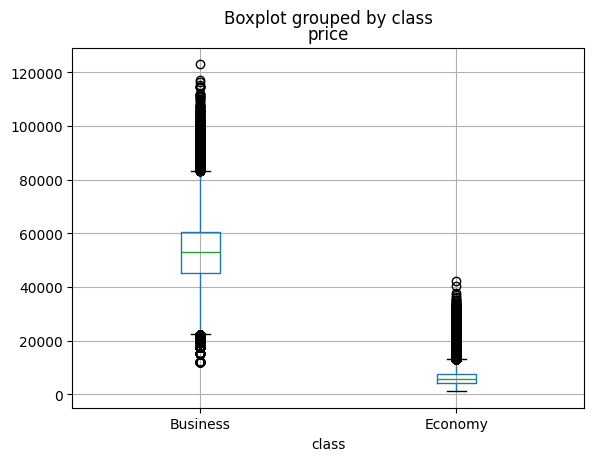

In [34]:
df.boxplot(column='price', by='class')
plt.show()